Perform the following operations using Python on any open source dataset (e.g., data.csv)
1. Import all the required Python Libraries.
2. Locate an open source data from the web (e.g., https://www.kaggle.com). Provide a clear description of the
data and its source (i.e., URL of the web site).
3. Load the Dataset into pandas dataframe.
4. Data Preprocessing: check for missing values in the data using pandas isnull(), describe() function to get
some initial statistics. Provide variable descriptions. Types of variables etc. Check the dimensions of the
data frame.
5. Data Formatting and Data Normalization: Summarize the types of variables by checking the data types (i.e.,
character, numeric, integer, factor, and logical) of the variables in the data set. If variables are not in the
correct data type, apply proper type conversions.
6. Turn categorical variables into quantitative variables in Python.

In [1]:
#Importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Reading the dataset
df = pd.read_csv("Auto.csv")
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130.0,3504.0,12.0,70.0,1.0,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70.0,1.0,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70.0,1.0,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70.0,1.0,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70.0,NaN,ford torino


In [3]:
df.tail()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
387,27.0,4,140.0,86.0,2790.0,15.6,82.0,1.0,ford mustang gl
388,44.0,4,97.0,52.0,2130.0,24.6,82.0,2.0,vw pickup
389,32.0,4,135.0,84.0,2295.0,11.6,82.0,1.0,dodge rampage
390,28.0,4,120.0,79.0,2625.0,18.6,82.0,1.0,ford ranger
391,31.0,4,119.0,82.0,2720.0,19.4,82.0,1.0,chevy s-10


In [4]:
print("\nStatistical Summary:")
#Descriptive statistics
print(df.describe())


Statistical Summary:
              mpg   cylinders  displacement  horsepower       weight  \
count  392.000000  392.000000    392.000000  390.000000   391.000000   
mean    23.445918    5.471939    194.411990  104.471795  2978.365729   
std      7.805007    1.705783    104.644004   38.584571   850.349703   
min      9.000000    3.000000     68.000000   46.000000  1613.000000   
25%     17.000000    4.000000    105.000000   75.000000  2224.500000   
50%     22.750000    4.000000    151.000000   92.500000  2807.000000   
75%     29.000000    8.000000    275.750000  128.000000  3616.500000   
max     46.600000    8.000000    455.000000  230.000000  5140.000000   

       acceleration        year      origin  
count    391.000000  391.000000  387.000000  
mean      15.489003   75.994885    1.583979  
std        2.853878    3.675975    0.808024  
min        0.500000   70.000000    1.000000  
25%       13.700000   73.000000    1.000000  
50%       15.500000   76.000000    1.000000  
75%    

In [5]:
#Printing Shapes and Size of the dataset
print("\nShape of the dataset:", df.shape)
print("Size of the dataset:", df.size)


Shape of the dataset: (392, 9)
Size of the dataset: 3528


In [6]:
#Checking for missing values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
mpg             0
cylinders       0
displacement    0
horsepower      2
weight          1
acceleration    1
year            1
origin          5
name            0
dtype: int64


In [7]:
#Handling missing values by filling them with the mean of the respective columns
df.fillna(df.mean(numeric_only=True), inplace=True)
print(df.isnull().sum())

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
year            0
origin          0
name            0
dtype: int64


In [8]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130.0,3504.0,12.0,70.0,1.000000,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70.0,1.000000,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70.0,1.000000,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70.0,1.000000,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70.0,1.583979,ford torino


In [9]:
print("\nShape of Data:", df.shape)
print("Total Elements:", df.size)


Shape of Data: (392, 9)
Total Elements: 3528


In [10]:
#Displaying the data types of each column
print(df.dtypes)

mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight          float64
acceleration    float64
year            float64
origin          float64
name             object
dtype: object


In [11]:
#Converting categorical variables to numerical variables
if 'engine-location' in df.columns:
    df['engine-location'] = df['engine-location'].astype('category')

if 'horsepower' in df.columns:
    df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')

In [12]:
numeric_cols = df.select_dtypes(include=np.number).columns

In [13]:
#Normalizing the numeric columns using Min-Max scaling
for col in numeric_cols:
    df[col] = (df[col] - df[col].min()) / (df[col].max() - df[col].min())

In [14]:
print("\nAfter Normalization:")
df.head()


After Normalization:


,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,0.239362,1.0,0.617571,0.456522,0.536150,0.473251,0.0,0.00000,chevrolet chevelle malibu
1,0.159574,1.0,0.728682,0.646739,0.589736,0.452675,0.0,0.00000,buick skylark 320
2,0.239362,1.0,0.645995,0.565217,0.516870,0.432099,0.0,0.00000,plymouth satellite
3,0.186170,1.0,0.609819,0.565217,0.516019,0.473251,0.0,0.00000,amc rebel sst
4,0.212766,1.0,0.604651,0.510870,0.520556,0.411523,0.0,0.29199,ford torino


In [15]:
#Converting categorical variables to numerical variables
df_encoded = pd.get_dummies(df)
df_encoded.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name_amc ambassador brougham,name_amc ambassador dpl,...,name_volvo 145e (sw),name_volvo 244dl,name_volvo 245,name_volvo 264gl,name_volvo diesel,name_vw dasher (diesel),name_vw pickup,name_vw rabbit,name_vw rabbit c (diesel),name_vw rabbit custom
0,0.239362,1.0,0.617571,0.456522,0.536150,0.473251,0.0,0.00000,False,False,...,False,False,False,False,False,False,False,False,False,False
1,0.159574,1.0,0.728682,0.646739,0.589736,0.452675,0.0,0.00000,False,False,...,False,False,False,False,False,False,False,False,False,False
2,0.239362,1.0,0.645995,0.565217,0.516870,0.432099,0.0,0.00000,False,False,...,False,False,False,False,False,False,False,False,False,False
3,0.186170,1.0,0.609819,0.565217,0.516019,0.473251,0.0,0.00000,False,False,...,False,False,False,False,False,False,False,False,False,False
4,0.212766,1.0,0.604651,0.510870,0.520556,0.411523,0.0,0.29199,False,False,...,False,False,False,False,False,False,False,False,False,False


In [16]:
print("\nAfter Encoding:")
print(df_encoded.head())


After Encoding:
        mpg  cylinders  displacement  horsepower    weight  acceleration  \
0  0.239362        1.0      0.617571    0.456522  0.536150      0.473251   
1  0.159574        1.0      0.728682    0.646739  0.589736      0.452675   
2  0.239362        1.0      0.645995    0.565217  0.516870      0.432099   
3  0.186170        1.0      0.609819    0.565217  0.516019      0.473251   
4  0.212766        1.0      0.604651    0.510870  0.520556      0.411523   

   year   origin  name_amc ambassador brougham  name_amc ambassador dpl  ...  \
0   0.0  0.00000                         False                    False  ...   
1   0.0  0.00000                         False                    False  ...   
2   0.0  0.00000                         False                    False  ...   
3   0.0  0.00000                         False                    False  ...   
4   0.0  0.29199                         False                    False  ...   

   name_volvo 145e (sw)  name_volvo 244dl  na

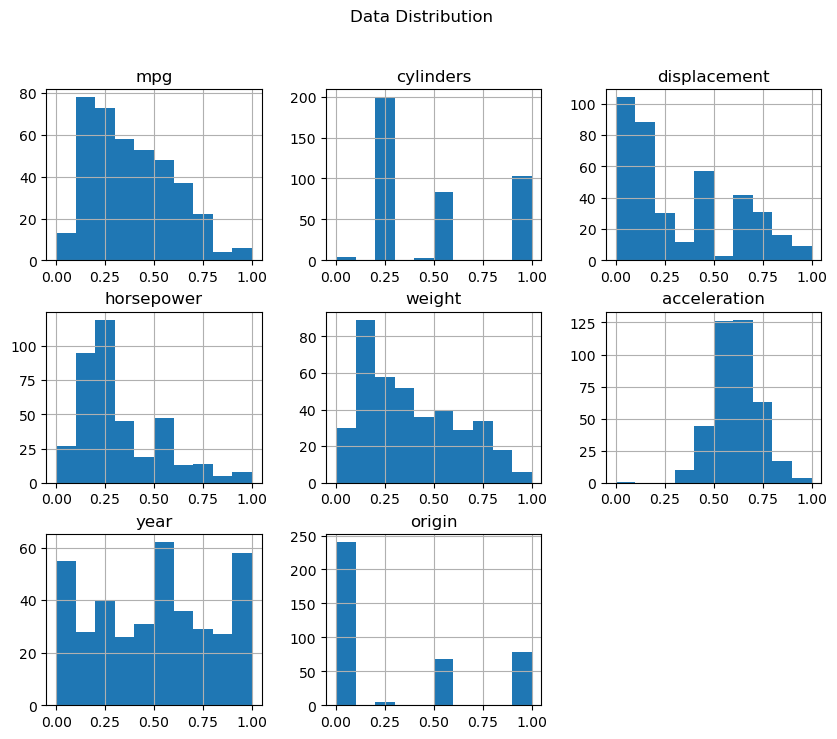

In [17]:
#Visualizing the distribution of the data
df_encoded.hist(figsize=(10,8))
plt.suptitle("Data Distribution")
plt.show()

Text(0.5, 1.0, 'Correlation Heatmap')

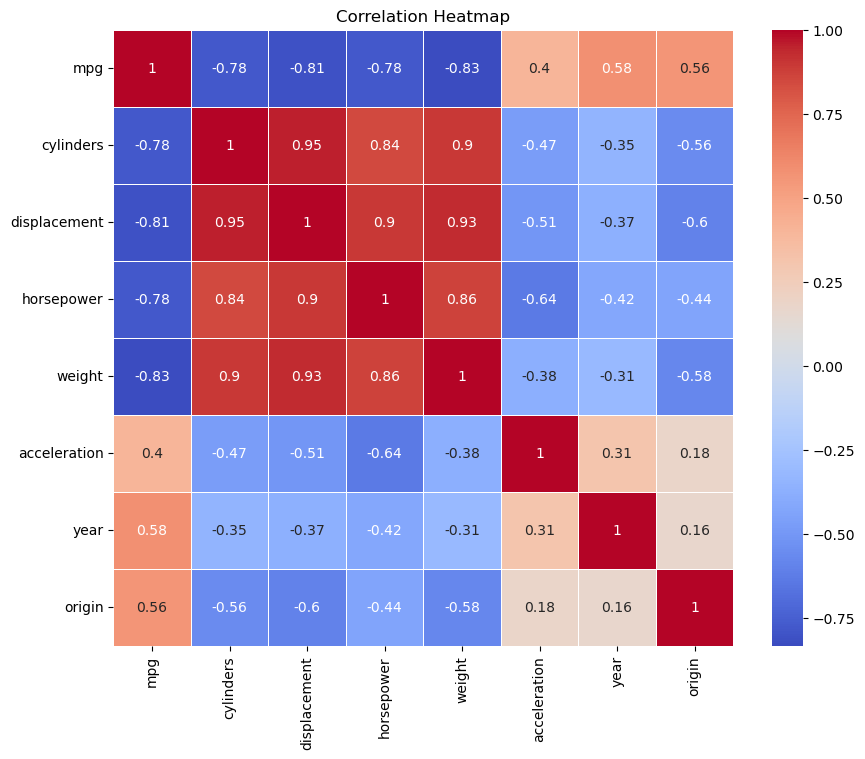

In [18]:
#plotting heatmap for numerical columns
plt.figure(figsize=(10,8))
new_df = df_encoded.select_dtypes(include=np.number)
sns.heatmap(new_df.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")